In [85]:
import requests
import pandas as pd
import numpy as np
from io import StringIO
import lxml

In [86]:
url = 'https://uk.wikipedia.org/wiki/Населення_України'
headers = {"User-Agent":"Chrome/117.0.0.0 Safari/537.36"}
html = requests.get(url, headers=headers).text
df = pd.read_html(StringIO(html))[13]
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.0,206.0,160.0,130,73,126,—,—
1,Вінницька,224.0,192.0,142.0,124,84,112,109,76
2,Волинська,247.0,250.0,179.0,153,112,148,141,101
3,Дніпропетровська,204.0,204.0,151.0,123,71,112,111,71
4,Донецька,271.0,214.0,140.0,109,61,98,82,—
5,Житомирська,261.0,223.0,159.0,129,89,122,120,79
6,Закарпатська,314.0,273.0,207.0,168,115,151,146,104
7,Запорізька,219.0,197.0,150.0,124,71,106,106,68
8,Івано-Франківська,243.0,248.0,182.0,155,103,124,122,88
9,Київська,204.0,189.0,156.0,123,73,122,121,80


In [87]:
# Вивести перші рядки таблиці за допомогою методу head
df.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.0,206.0,160.0,130,73,126,—,—
1,Вінницька,224.0,192.0,142.0,124,84,112,109,76
2,Волинська,247.0,250.0,179.0,153,112,148,141,101
3,Дніпропетровська,204.0,204.0,151.0,123,71,112,111,71
4,Донецька,271.0,214.0,140.0,109,61,98,82,—


In [88]:
# Визначте кількість рядків та стовпців у датафреймі (атрибут shape)
df.shape

(28, 9)

In [89]:
# Замініть у таблиці значення "—" на значення NaN
df.iloc[:,1:] = df.iloc[:,1:].apply(pd.to_numeric, errors='coerce')
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.0,206.0,160.0,130,73,126,NaN,NaN
1,Вінницька,224.0,192.0,142.0,124,84,112,109.0,76.0
2,Волинська,247.0,250.0,179.0,153,112,148,141.0,101.0
3,Дніпропетровська,204.0,204.0,151.0,123,71,112,111.0,71.0
4,Донецька,271.0,214.0,140.0,109,61,98,82.0,NaN
5,Житомирська,261.0,223.0,159.0,129,89,122,120.0,79.0
6,Закарпатська,314.0,273.0,207.0,168,115,151,146.0,104.0
7,Запорізька,219.0,197.0,150.0,124,71,106,106.0,68.0
8,Івано-Франківська,243.0,248.0,182.0,155,103,124,122.0,88.0
9,Київська,204.0,189.0,156.0,123,73,122,121.0,80.0


In [90]:
# Визначте типи всіх стовпців за допомогою dataframe.dtypes
df.dtypes

Регіон     object
1950      float64
1960      float64
1970      float64
1990        int64
2000        int64
2012        int64
2014       object
2019       object
dtype: object

In [91]:
# Замініть типи нечислових колонок на числові
# зроблено вище

In [92]:
# Порахуйте, яка частка пропусків міститься в кожній колонці
missing_count = df.isnull().sum()
missing_perc = df.isnull().sum() / len(df) * 100

mis_info = pd.DataFrame({'missing count':missing_count, 'missing %':missing_perc.round(1)})
mis_info

,missing count,missing %
Регіон,0,0.0
1950,2,7.1
1960,1,3.6
1970,1,3.6
1990,0,0.0
2000,0,0.0
2012,0,0.0
2014,2,7.1
2019,4,14.3


In [93]:
# Видаліть з таблиці дані по всій країні, останній рядок таблиці
df = df[:-1]
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,230.0,206.0,160.0,130,73,126,NaN,NaN
1,Вінницька,224.0,192.0,142.0,124,84,112,109.0,76.0
2,Волинська,247.0,250.0,179.0,153,112,148,141.0,101.0
3,Дніпропетровська,204.0,204.0,151.0,123,71,112,111.0,71.0
4,Донецька,271.0,214.0,140.0,109,61,98,82.0,NaN
5,Житомирська,261.0,223.0,159.0,129,89,122,120.0,79.0
6,Закарпатська,314.0,273.0,207.0,168,115,151,146.0,104.0
7,Запорізька,219.0,197.0,150.0,124,71,106,106.0,68.0
8,Івано-Франківська,243.0,248.0,182.0,155,103,124,122.0,88.0
9,Київська,204.0,189.0,156.0,123,73,122,121.0,80.0


In [94]:
# Оскільки дані з першоджерела відрізняются від зпарсених на 1 крапку, треба додати ще 1 крок - поділити на 10
df = df.copy()

cols = df.columns[1:]
df[cols] = df[cols].astype("float64") / 10
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,NaN,NaN
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,NaN
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


In [95]:
# Замініть відсутні дані в стовпцях середніми значеннями цих стовпців (метод fillna)
mean = df[cols].mean()
df[cols] = df[cols].fillna(mean).round(1)
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,11.1,8.0
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,8.0
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


In [96]:
# Отримайте список регіонів, де рівень народжуваності у 2019 році був вищим за середній по Україні

avg_2019 = df['2019'].mean()
regions_above_avg = df.loc[df['2019'] > avg_2019, ['Регіон','2019']]
regions_above_avg


,Регіон,2019
2,Волинська,10.1
6,Закарпатська,10.4
8,Івано-Франківська,8.8
12,Львівська,8.7
14,Одеська,8.8
16,Рівненська,10.7
20,Херсонська,8.1
23,Чернівецька,9.2
25,Київ,11.0


In [97]:
# У якому регіоні була найвища народжуваність у 2014 році?
max_region_2014 = df.loc[df['2014'].idxmax(),['Регіон','2014']]
max_region_2014

Регіон    Рівненська
2014            14.8
Name: 16, dtype: object

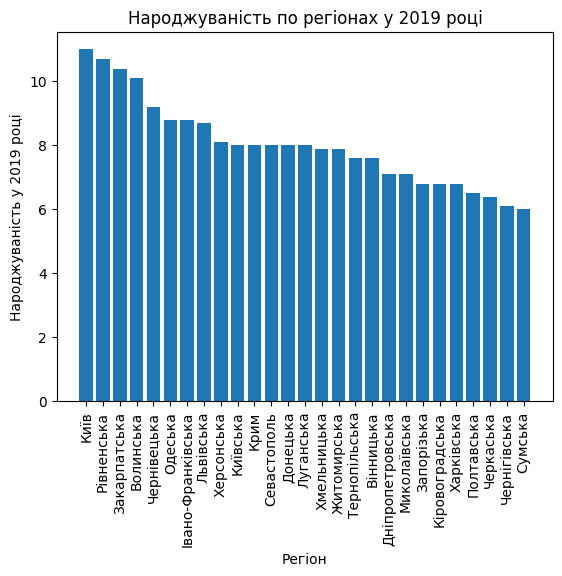

In [98]:
# Побудуйте стовпчикову діаграму народжуваності по регіонах у 2019 році
import matplotlib.pyplot as plt
%matplotlib inline

df_sort = df.sort_values(by='2019', ascending=False)

plt.figure() # новое полотно для диаграммы
plt.bar(df_sort['Регіон'], df_sort['2019'])
plt.xticks(rotation=90) # потворот подписей вертикально
plt.xlabel('Регіон')
plt.ylabel('Народжуваність у 2019 році')
plt.title('Народжуваність по регіонах у 2019 році')
plt.show()


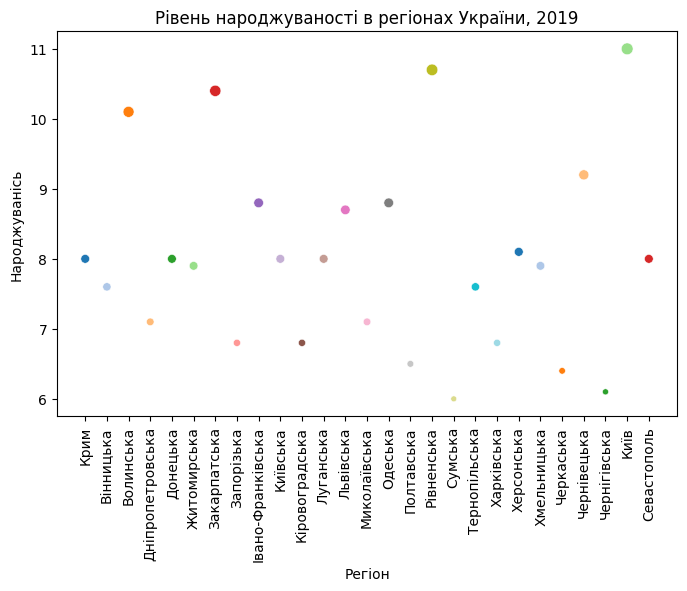

In [99]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x='Регіон', y='2019', hue='Регіон', size='2019', s=100, palette='tab20' )
plt.title('Рівень народжуваності в регіонах України, 2019')
plt.xlabel('Регіон')
plt.ylabel('Народжуванісь')
plt.xticks(rotation=90)
plt.legend([],[], frameon=False) 

plt.show()

In [100]:
!pip install geopandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


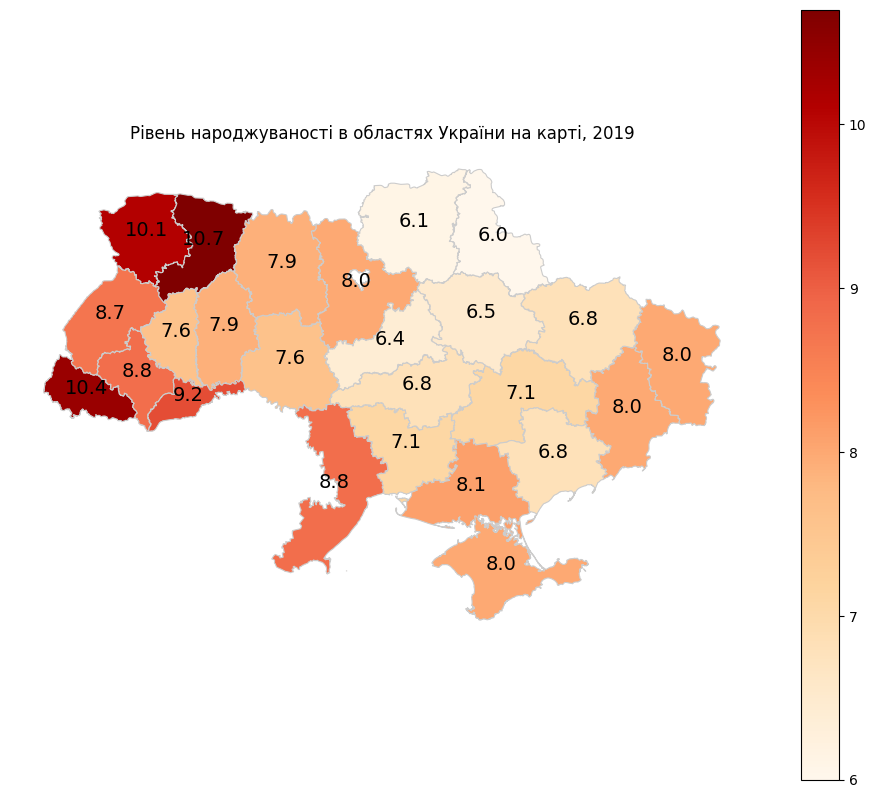

In [101]:
import geopandas as gpd

ukraine_map = gpd.read_file("ua.json")
ukraine_map.name

df['name'] = [
'Avtonomna Respublika Krym','Vinnytska','Volynska','Dnipropetrovska','Donetska',
'Zhytomyrska','Zakarpatska','Zaporizka','Ivano-Frankivska','Kyivska',
'Kirovohradska','Luhanska','Lvivska','Mykolaivska','Odeska','Poltavska',
'Rivnenska','Sumska','Ternopilska','Kharkivska','Khersonska','Khmelnytska',
'Cherkaska','Chernivetska','Chernihivska','Kyivska','Sevastopilska'
]

df_wo_capital = df[(df['Регіон'] != 'Київ') & (df['Регіон'] != 'Севастополь')]
birth_2019 = df_wo_capital[['name', '2019']].rename(columns={'2019':'birth_rate'})

ukraine = ukraine_map.merge(birth_2019, left_on='name', right_on='name', how='left')
ukraine = ukraine.drop_duplicates(subset='name')

fig, ax = plt.subplots(figsize=(12,10))
ukraine.plot(column='birth_rate',
             cmap='OrRd',
             linewidth=0.8,
             edgecolor='0.8',
             legend=True,
             ax=ax)

# підписи
for idx, row in ukraine.iterrows():
    if pd.notna(row['birth_rate']):
        x = row.geometry.centroid.x
        y = row.geometry.centroid.y
        ax.text(x, y, f"{row['birth_rate']:.1f}", ha='center', fontsize=14)

ax.set_title("Рівень народжуваності в областях України на карті, 2019")
ax.axis('off')

plt.show()